In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

COUGHVID_META  = Path("../data/coughvid/metadata.csv")
CAMBRIDGE_META = Path("../data/cambridge/participant_metadata.csv")
COUGHVID_AUDIO = Path("../data/coughvid/audio/coughvid_20211012")
CAMBRIDGE_AUDIO = Path("../data/cambridge/audio/covid_data/audio")

In [38]:
cv = pd.read_csv(COUGHVID_META)
print(cv.shape)
print(cv.dtypes)
cv.head()

(34434, 52)
Unnamed: 0                 int64
uuid                      object
datetime                  object
cough_detected           float64
latitude                 float64
longitude                float64
age                      float64
gender                    object
respiratory_condition     object
fever_muscle_pain         object
status                    object
status_SSL                object
quality_1                 object
cough_type_1              object
dyspnea_1                 object
wheezing_1                object
stridor_1                 object
choking_1                 object
congestion_1              object
nothing_1                 object
diagnosis_1               object
severity_1                object
quality_2                 object
cough_type_2              object
dyspnea_2                 object
wheezing_2                object
stridor_2                 object
choking_2                 object
congestion_2              object
nothing_2                 objec

,Unnamed: 0,uuid,datetime,cough_detected,latitude,longitude,age,gender,respiratory_condition,fever_muscle_pain,...,quality_4,cough_type_4,dyspnea_4,wheezing_4,stridor_4,choking_4,congestion_4,nothing_4,diagnosis_4,severity_4
0,0,00014dcc-0f06-4c27-8c7b-737b18a2cf4c,2020-11-25T18:58:50.488301+00:00,0.0155,48.9,2.4,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,00039425-7f3a-42aa-ac13-834aaa2b6b92,2020-04-13T21:30:59.801831+00:00,0.9609,31.3,34.8,15.0,male,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,0007c6f1-5441-40e6-9aaf-a761d8f2da3b,2020-10-18T15:38:38.205870+00:00,0.1643,NaN,NaN,46.0,female,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,00098cdb-4da1-4aa7-825a-4f1b9abc214b,2021-01-22T22:08:06.742577+00:00,0.1133,47.4,9.4,66.0,female,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,0009eb28-d8be-4dc1-92bb-907e53bc5c7a,2020-04-12T04:02:18.159383+00:00,0.9301,40.0,-75.1,34.0,male,True,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [39]:
print(cv['status'].value_counts(dropna=False))

status
healthy        15476
NaN            13770
symptomatic     3873
COVID-19        1315
Name: count, dtype: int64


In [40]:
cv_usable = cv[cv['status'].isin(['healthy', 'COVID-19'])].copy()
cv_usable['label'] = (cv_usable['status'] == 'COVID-19').astype(int)

print(f"Total usable: {len(cv_usable)}")
print(f"Healthy (0): {(cv_usable['label'] == 0).sum()}")
print(f"COVID-19 (1): {(cv_usable['label'] == 1).sum()}")
print(f"COVID-19 %: {cv_usable['label'].mean():.1%}")

Total usable: 16791
Healthy (0): 15476
COVID-19 (1): 1315
COVID-19 %: 7.8%


In [41]:
def find_audio_file(uid, audio_dir):
    for ext in ['.wav', '.ogg', '.webm']:
        p = audio_dir / f"{uid}{ext}"
        if p.exists():
            return str(p)
    return None

# Check on full usable set
cv_usable['audio_path'] = cv_usable['uuid'].apply(
    lambda uid: find_audio_file(uid, COUGHVID_AUDIO)
)

found = cv_usable['audio_path'].notna()
print(f"Audio found:   {found.sum()}")
print(f"Audio missing: {(~found).sum()}")

# Drop rows with no audio
cv_usable = cv_usable[found].copy()
print(f"\nFinal usable rows: {len(cv_usable)}")
print(f"COVID-19 %: {cv_usable['label'].mean():.1%}")

Audio found:   16791
Audio missing: 0

Final usable rows: 16791
COVID-19 %: 7.8%


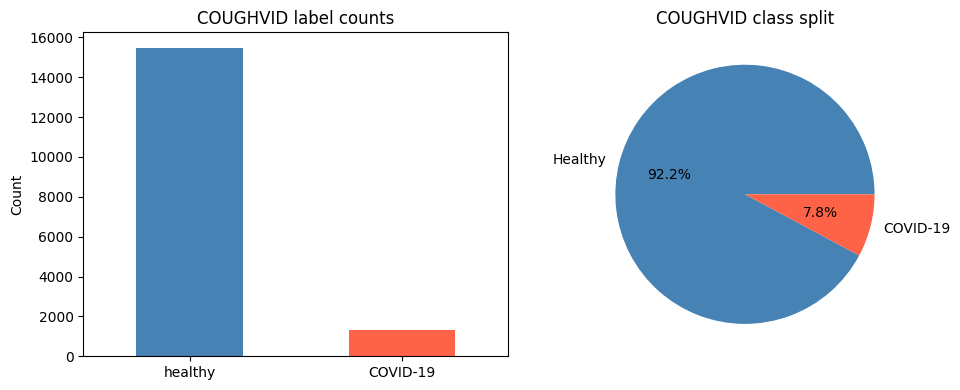

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
cv_usable['status'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'])
axes[0].set_title('COUGHVID label counts')
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
axes[1].pie(
    cv_usable['status'].value_counts(),
    labels=['Healthy', 'COVID-19'],
    autopct='%1.1f%%',
    colors=['steelblue', 'tomato']
)
axes[1].set_title('COUGHVID class split')

plt.tight_layout()
plt.savefig('../outputs/coughvid_label_dist.png', dpi=150, bbox_inches='tight')
plt.show()

In [43]:
cam = pd.read_csv(CAMBRIDGE_META)
print(cam.shape)
print(cam.columns.tolist())
cam.head()

(72999, 41)
['participant_identifier', 'survey_phase', 'recruitment_source', 'submission_date', 'submission_delay', 'age', 'gender', 'region_name', 'wearing_mask', 'covid_test_result', 'covid_test_method', 'covid_test_date', 'covid_test_processed_date', 'covid_ct_value', 'covid_ct_gene', 'covid_ct_mean', 'covid_viral_load', 'covid_viral_load_category', 'symptom_onset', 'symptom_none', 'symptom_cough_any', 'symptom_new_continuous_cough', 'symptom_runny_or_blocked_nose', 'symptom_shortness_of_breath', 'symptom_sore_throat', 'symptom_abdominal_pain', 'symptom_diarrhoea', 'symptom_fatigue', 'symptom_fever_high_temperature', 'symptom_headache', 'symptom_change_to_sense_of_smell_or_taste', 'symptom_loss_of_taste', 'symptom_other', 'symptom_prefer_not_to_say', 'smoker_status', 'respiratory_condition_asthma', 'respiratory_condition_other', 'influenza_a_test_result', 'influenza_a_ct_value', 'influenza_b_test_result', 'influenza_b_ct_value']


,participant_identifier,survey_phase,recruitment_source,submission_date,submission_delay,age,gender,region_name,wearing_mask,covid_test_result,...,symptom_loss_of_taste,symptom_other,symptom_prefer_not_to_say,smoker_status,respiratory_condition_asthma,respiratory_condition_other,influenza_a_test_result,influenza_a_ct_value,influenza_b_test_result,influenza_b_ct_value
0,P0038428,beta,Test and Trace,509,2.0,45-64,Female,K,No,Positive,...,1,0,0,Ex-smoker,0.0,0.0,NaN,NaN,NaN,NaN
1,P0050280,alpha,Test and Trace,351,3.0,18-44,Female,L,No,Positive,...,0,0,0,Ex-smoker,0.0,0.0,NaN,NaN,NaN,NaN
2,P0087659,beta,REACT,571,5.0,18-44,Male,K,No,Negative,...,0,0,0,Never smoked,0.0,0.0,Negative,0.0,Negative,0.0
3,P0080535,beta,REACT,523,1.0,18-44,Male,D,No,Negative,...,0,0,0,Never smoked,0.0,0.0,NaN,NaN,NaN,NaN
4,P0033414,beta,REACT,538,1.0,45-64,Male,L,No,Negative,...,0,0,0,Never smoked,0.0,0.0,NaN,NaN,NaN,NaN


In [44]:
print(cam['covid_test_result'].value_counts(dropna=False))
print(f"\nTest method breakdown:")
print(cam['covid_test_method'].value_counts(dropna=False))

covid_test_result
Negative    47036
Positive    25706
NaN           257
Name: count, dtype: int64

Test method breakdown:
covid_test_method
RT-qPCR    68068
ePCR        2718
LFT         1925
LAMP         244
NaN           27
Unknown        9
PCR            8
Name: count, dtype: int64


In [45]:
# Keep only PCR-confirmed results
pcr_methods = ['RT-qPCR', 'ePCR', 'PCR']
cam_pcr = cam[cam['covid_test_method'].isin(pcr_methods)].copy()
cam_pcr = cam_pcr[cam_pcr['covid_test_result'].isin(['Positive', 'Negative'])].copy()

cam_pcr['label'] = (cam_pcr['covid_test_result'] == 'Positive').astype(int)

print(f"PCR-confirmed rows: {len(cam_pcr)}")
print(f"Positive: {(cam_pcr['label'] == 1).sum()}")
print(f"Negative: {(cam_pcr['label'] == 0).sum()}")
print(f"Positive %: {cam_pcr['label'].mean():.1%}")

# Check for duplicate participant IDs
print(f"\nUnique participants: {cam_pcr['participant_identifier'].nunique()}")
print(f"Total rows: {len(cam_pcr)}")

PCR-confirmed rows: 70565
Positive: 24105
Negative: 46460
Positive %: 34.2%

Unique participants: 70565
Total rows: 70565


In [46]:
# List all wav files in cambridge audio folder
audio_files = list(CAMBRIDGE_AUDIO.glob("**/*.wav"))
print(f"Total wav files found: {len(audio_files)}")

# Look at a few filenames to understand naming convention
for f in audio_files[:5]:
    print(f.name)

Total wav files found: 218097
100000_5U33BP0RsrHahqzS.wav
100000_DEIxVgXjiCfrjZ2n.wav
100000_iMwMz0ma2M8eIT0F.wav
100001_Fa6AqfTbcTtavnYZ.wav
100001_U09M5CtZMmughofX.wav


In [47]:
# Look at a wider sample of filenames
for f in audio_files[::10000]:  # every 10,000th file
    print(f.name)

100000_5U33BP0RsrHahqzS.wav
107191_sTlnsOlGbYFREsRS.wav
113970_QR4PKuw2PxVEqouq.wav
120731_diz6TbuL78C3TuP9.wav
129001_sa4UqMkLeAUsqKZy.wav
13922_KhAT4d2MjSBDvfWR.wav
146101_CH0QyrVnZ6gsK6T1.wav
154239_5l6TasI4XBrDa4Jf.wav
22735_iqEyGsxKV6ubjq8D.wav
3187_MVrfkXrcf2Z6wuN7.wav
3929_fjhN3BO928Kntuxu.wav
45885_W2mBgy7uRahmKjot.wav
52828_J5TRiVctOZcOLDva.wav
62-12-04023bd9-91bb-416b-92390508b6c8e5bd.wav
62-13-f8111093-d65d-4993-a5651f0c0605dc43.wav
65281_PEomlF57Lpab0RuN.wav
71-12-3ab4439d-b046-4eff-a300445b6fa553fc.wav
71-13-6ab8de0c-c214-48d4-bb18d6bc00ae955d.wav
71-14-991d4358-62f1-4838-b107da3107342596.wav
75672_r3hrRVpn2zuDX7VT.wav
83330_cJodrXwTK2gXsL6K.wav
9211_ACfB7ibP1QqbrIkX.wav


In [49]:
# Sample IDs from audio filenames
audio_sample = audio_df['participant_identifier'].head(10).tolist()
print("Audio filename IDs:")
print(audio_sample)

# Sample IDs from metadata
meta_sample = cam_pcr['participant_identifier'].head(10).tolist()
print("\nMetadata IDs:")
print(meta_sample)

Audio filename IDs:
['100000', '100000', '100000', '100001', '100001', '100001', '100005', '100005', '100005', '100006']

Metadata IDs:
['P0038428', 'P0050280', 'P0087659', 'P0080535', 'P0033414', 'P0045888', 'P0050093', 'P0088273', 'P0043519', 'P0054343']


In [50]:
audio_meta = pd.read_csv(Path("../data/cambridge/audio_metadata.csv"))
print(audio_meta.shape)
print(audio_meta.columns.tolist())
audio_meta.head()

(72999, 26)
['participant_identifier', 'exhalation_file_name', 'exhalation_size', 'exhalation_sample_rate', 'exhalation_frames', 'exhalation_channels', 'exhalation_length', 'exhalation_amplitude', 'exhalation_snr', 'cough_file_name', 'cough_size', 'cough_sample_rate', 'cough_frames', 'cough_channels', 'cough_length', 'cough_amplitude', 'cough_snr', 'three_cough_file_name', 'three_cough_size', 'three_cough_sample_rate', 'three_cough_frames', 'three_cough_channels', 'three_cough_length', 'three_cough_amplitude', 'three_cough_snr', 'missing_audio']


,participant_identifier,exhalation_file_name,exhalation_size,exhalation_sample_rate,exhalation_frames,exhalation_channels,exhalation_length,exhalation_amplitude,exhalation_snr,cough_file_name,...,cough_snr,three_cough_file_name,three_cough_size,three_cough_sample_rate,three_cough_frames,three_cough_channels,three_cough_length,three_cough_amplitude,three_cough_snr,missing_audio
0,P0053857,62-12-a04e5d89-e660-4351-900d399932aeb272.wav,696364.0,48000.0,348160.0,1.0,7.253333,23291.0,0.228033,62-13-e0b8f181-3a3e-4c6f-94e4664b969f1415.wav,...,0.336768,62-14-4f29523d-6ee0-43f1-8cddd45ca48e736f.wav,1040428.0,48000.0,520192.0,1.0,10.837333,22401.0,0.324542,False
1,P0050416,62-12-8b9aa0e5-9d57-444f-ad716fa35be81037.wav,524332.0,48000.0,262144.0,1.0,5.461333,32768.0,0.254624,62-13-f46ea04d-ec8a-4f54-a17fdab702973d32.wav,...,0.403061,62-14-693d8280-2b52-46ee-9ad0ae0d1062dd91.wav,950316.0,48000.0,475136.0,1.0,9.898667,32768.0,0.327760,False
2,P0062406,62-12-da6b16dc-59a8-446f-9af29bb35dfe36cb.wav,557100.0,48000.0,278528.0,1.0,5.802667,32357.0,0.253395,62-13-8365ff12-607d-4441-9bcab8c74ea007fc.wav,...,0.223105,62-14-97ef50db-868d-4db4-81ba140a70d65ec5.wav,688172.0,48000.0,344064.0,1.0,7.168000,32768.0,0.266505,False
3,P0033507,62-12-0e149bf2-80ff-44df-9bafdeb22782cd5c.wav,458796.0,48000.0,229376.0,1.0,4.778667,1044.0,0.368350,62-13-89689442-7303-4ee5-a1f834b7ee701d39.wav,...,0.296211,62-14-ddbfcbba-ff6e-43b8-b3ea93e08bb6777a.wav,458796.0,48000.0,229376.0,1.0,4.778667,14600.0,0.352609,False
4,P0069728,62-12-d6fb699c-406d-43ac-bc4bc15bbc11bd29.wav,557100.0,48000.0,278528.0,1.0,5.802667,27425.0,0.363994,62-13-e343e058-6fb4-4a34-bca17811000a46f6.wav,...,0.303160,62-14-291732a4-9a05-4ab6-96a16ab19fc5e481.wav,491564.0,48000.0,245760.0,1.0,5.120000,28561.0,0.306807,False


In [51]:
audio_meta = pd.read_csv(Path("../data/cambridge/audio_metadata.csv"))

# Join audio metadata with PCR labels on participant_identifier
cam_merged = audio_meta.merge(
    cam_pcr[['participant_identifier', 'label', 'covid_test_result']],
    on='participant_identifier',
    how='inner'
)

# Keep only cough recordings, drop missing audio
cam_merged = cam_merged[cam_merged['missing_audio'] == False].copy()
cam_merged = cam_merged[cam_merged['cough_file_name'].notna()].copy()

# Build full audio path
cam_merged['audio_path'] = cam_merged['cough_file_name'].apply(
    lambda f: str(CAMBRIDGE_AUDIO / f)
)

# Keep only what we need
cam_final = cam_merged[['participant_identifier', 'audio_path', 'label', 'covid_test_result']].copy()

print(f"Total rows:         {len(cam_final)}")
print(f"Unique participants: {cam_final['participant_identifier'].nunique()}")
print(f"Positive (COVID):   {(cam_final['label'] == 1).sum()}")
print(f"Negative:           {(cam_final['label'] == 0).sum()}")
print(f"Positive %:         {cam_final['label'].mean():.1%}")

Total rows:         68791
Unique participants: 68791
Positive (COVID):   23582
Negative:           45209
Positive %:         34.3%


In [52]:
cam_final['file_exists'] = cam_final['audio_path'].apply(lambda p: Path(p).exists())

print(f"Files found:   {cam_final['file_exists'].sum()}")
print(f"Files missing: {(~cam_final['file_exists']).sum()}")

cam_final = cam_final[cam_final['file_exists']].copy()
print(f"\nFinal Cambridge rows: {len(cam_final)}")
print(f"Positive %: {cam_final['label'].mean():.1%}")

Files found:   68791
Files missing: 0

Final Cambridge rows: 68791
Positive %: 34.3%


In [53]:
print("=" * 40)
print("DATASET SUMMARY")
print("=" * 40)
print(f"\nCOUGHVID (training)")
print(f"  Total recordings: {len(cv_usable)}")
print(f"  Healthy (0):      {(cv_usable['label'] == 0).sum()}")
print(f"  COVID-19 (1):     {(cv_usable['label'] == 1).sum()}")
print(f"  Positive %:       {cv_usable['label'].mean():.1%}")

print(f"\nCambridge (cross-dataset test)")
print(f"  Total recordings: {len(cam_final)}")
print(f"  Negative (0):     {(cam_final['label'] == 0).sum()}")
print(f"  Positive (1):     {(cam_final['label'] == 1).sum()}")
print(f"  Positive %:       {cam_final['label'].mean():.1%}")

DATASET SUMMARY

COUGHVID (training)
  Total recordings: 16791
  Healthy (0):      15476
  COVID-19 (1):     1315
  Positive %:       7.8%

Cambridge (cross-dataset test)
  Total recordings: 68791
  Negative (0):     45209
  Positive (1):     23582
  Positive %:       34.3%


In [54]:
cv_usable[['uuid', 'audio_path', 'label', 'status']].to_csv(
    '../data/coughvid/coughvid_clean.csv', index=False
)
cam_final[['participant_identifier', 'audio_path', 'label', 'covid_test_result']].to_csv(
    '../data/cambridge/cambridge_clean.csv', index=False
)

print("Saved:")
print("  data/coughvid/coughvid_clean.csv")
print("  data/cambridge/cambridge_clean.csv")

Saved:
  data/coughvid/coughvid_clean.csv
  data/cambridge/cambridge_clean.csv


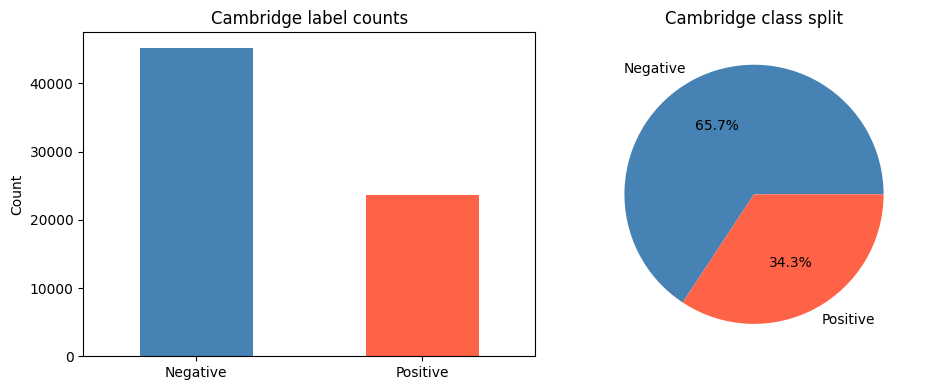

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cam_final['covid_test_result'].value_counts().plot(
    kind='bar', ax=axes[0], color=['steelblue', 'tomato']
)
axes[0].set_title('Cambridge label counts')
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

axes[1].pie(
    cam_final['covid_test_result'].value_counts(),
    labels=['Negative', 'Positive'],
    autopct='%1.1f%%',
    colors=['steelblue', 'tomato']
)
axes[1].set_title('Cambridge class split')

plt.tight_layout()
plt.savefig('../outputs/cambridge_label_dist.png', dpi=150, bbox_inches='tight')
plt.show()

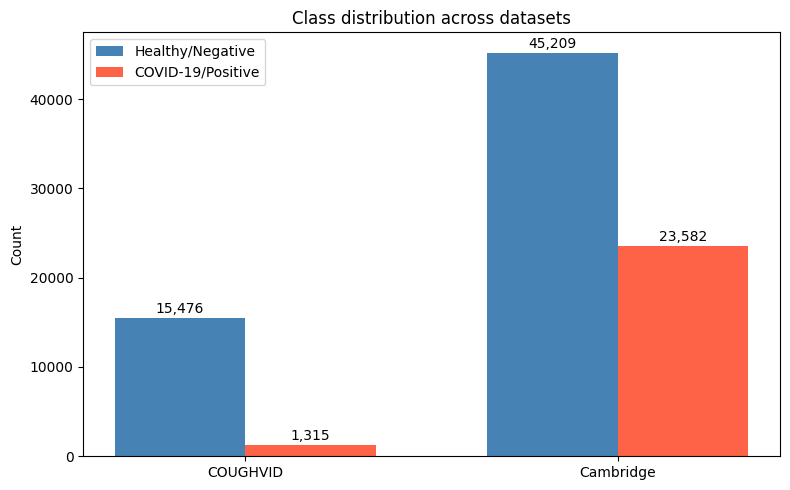

In [56]:
fig, ax = plt.subplots(figsize=(8, 5))

datasets = ['COUGHVID', 'Cambridge']
healthy  = [15476, 45209]
covid    = [1315, 23582]

x = np.arange(len(datasets))
width = 0.35

bars1 = ax.bar(x - width/2, healthy, width, label='Healthy/Negative', color='steelblue')
bars2 = ax.bar(x + width/2, covid,   width, label='COVID-19/Positive', color='tomato')

ax.set_title('Class distribution across datasets')
ax.set_ylabel('Count')
ax.set_xticks(x)
ax.set_xticklabels(datasets)
ax.legend()

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/dataset_comparison.png', dpi=150, bbox_inches='tight')
plt.show()